# 01 Linear probe (encodeur de phrases GELÉ + LogReg)

**Modèle plat** (Silla & Freitas 2011) = approche plate ; **linear probe**
(Alain & Bengio 2017) = régression logistique sur des embeddings **gelés**.

Métriques : plates (accuracy / macro-F1) **et** hiérarchiques (hF1 set + hF1-AUC,
Plaud 2024)

In [101]:
import os, sys
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")

import helpers as h
DEVICE = h.get_device()
os.makedirs("artifacts", exist_ok=True)

[device] using 'mps' (cuda=False, mps=True) | torch 2.11.0


## Données, taxonomie, splits & embeddings gelés

In [102]:
df, _ = h.load_m9()
df["_id"] = np.arange(len(df))
tax = h.Taxonomy.from_leaves(df.leaf_label.unique())
splits = h.make_balanced_splits(df, seeds=h.SEEDS)
# FROZEN raw sentence embeddings (= linear-probe features = "before SetFit").
emb_all = h.cached_st_embeddings(df.text.tolist(),
                                 cache_path="artifacts/st_emb_all.npy",
                                 name=h.ENCODER_NAME, device=DEVICE)
print("emb_all:", emb_all.shape, "| seeds:", h.SEEDS)

emb_all: (234, 768) | seeds: [0, 1, 2, 3, 4]


## Entraînement + évaluation sur les 5 seeds

_Sonde linéaire (Silla & Freitas 2011) : régression logistique multinomiale sur les embeddings gelés, prédisant la feuille.  
Projection des probabilités par feuille vers des marginales de nœuds cohérentes avec les ancêtres._

In [103]:
def fit_flat(emb_train, leaves_train, seed=0):
    """Fit a multinomial LogReg on frozen embeddings, predicting the leaf."""
    from sklearn.linear_model import LogisticRegression

    clf = LogisticRegression(max_iter=2000, random_state=seed, class_weight="balanced")
    clf.fit(emb_train, list(leaves_train))
    return clf


In [104]:
def run_seed(seed):
    """R8 linear probe: full n_train=8 train split."""
    tr, te = splits[seed]["train"], splits[seed]["test"]
    Xtr, Xte = emb_all[tr._id.values], emb_all[te._id.values]
    clf = fit_flat(Xtr, tr.leaf_label, seed=seed)
    prob = clf.predict_proba(Xte)
    pred = list(clf.predict(Xte))
    marg = h.flat_leaf_probs_to_marginals(prob, clf.classes_, tax)
    return pred, marg, h.all_metrics(pred, marg, te.leaf_label.tolist(), tax), te, prob


def run_seed3(seed):
    tr, te = splits[seed]["train"], splits[seed]["test"]
    tr3 = h.head_per_leaf(tr, 3)                    
    Xtr, Xte = emb_all[tr3._id.values], emb_all[te._id.values]
    clf = fit_flat(Xtr, tr3.leaf_label, seed=seed)  
    prob = clf.predict_proba(Xte)
    pred = list(clf.predict(Xte))
    marg = h.flat_leaf_probs_to_marginals(prob, clf.classes_, tax)
    return pred, marg, h.all_metrics(pred, marg, te.leaf_label.tolist(), tax), te, prob


def emit_system(MODEL, run_fn):
    """Per-system seed loop + full artifact family : long-format metrics CSV +
    provenance .meta.json + probs/correct npz (str(seed) keys) + seed-0 diagnostics."""
    import json
    rows, keep0 = [], {}
    probs_by_seed, correct_by_seed = {}, {}
    for seed in h.SEEDS:
        pred, marg, metrics, te, prob = run_fn(seed)
        for k, v in metrics.items():
            rows.append({"model": MODEL, "seed": seed, "metric": k, "value": v})
        probs_by_seed[str(seed)] = prob
        correct_by_seed[str(seed)] = np.asarray(pred) == te.leaf_label.values
        if seed == 0:
            keep0 = {"pred": pred, "marg": marg, "te": te}
        print(f"[{MODEL}] seed {seed}: " + "  ".join(f"{k}={v:.3f}" for k, v in metrics.items()))
    res = pd.DataFrame(rows)
    res.to_csv(f"artifacts/metrics_{MODEL}.csv", index=False)
    with open(f"artifacts/metrics_{MODEL}.csv.meta.json", "w") as fh:
        json.dump(h.provenance(), fh)           
    np.savez(f"artifacts/probs_{MODEL}.npz", **probs_by_seed)
    np.savez(f"artifacts/correct_{MODEL}.npz", **correct_by_seed)
    print(f"-> artifacts/metrics_{MODEL}.csv (+ .meta.json, probs/correct npz)")
    return res, keep0


def agg_metrics(res):
    return (res.groupby("metric").value.agg(["mean", "std"])
               .reindex(["leaf_accuracy", "leaf_macro_f1", "h_micro_f1",
                         "h_samples_f1", "h_macro_f1", "hf1_auc"]))


def diagnostics(MODEL, keep0):
    """Diagnostics trio for one system: confusion matrix (seed 0),
    top-10 confused pairs, and the errors_{MODEL}_seed0.csv export."""
    pred0, te0 = keep0["pred"], keep0["te"]
    labels = sorted(tax.terminals)
    fig, ax = plt.subplots(figsize=(10, 8))
    h.plot_confusion(te0.leaf_label.tolist(), pred0, labels=labels, ax=ax,
                     title=f"{MODEL} — confusion (seed 0)")
    plt.tight_layout(); plt.show()
    print(f"[{MODEL}] paires les plus confondues (seed 0):")
    display(h.top_confused_pairs(te0.leaf_label.tolist(), pred0, k=10))
    err = te0.assign(pred=pred0)
    err = err[err.leaf_label != err.pred]
    print(f"[{MODEL}] {len(err)}/{len(te0)} erreurs (seed 0)")
    err[["_id", "leaf_label", "pred", "text"]].to_csv(
        f"artifacts/errors_{MODEL}_seed0.csv", index=False)
    print(f"-> artifacts/errors_{MODEL}_seed0.csv")
    return err


In [105]:
res, keep0 = emit_system("linear_probe_8", run_seed)
res3, keep03 = emit_system("linear_probe_3", run_seed3)


[linear_probe_8] seed 0: leaf_accuracy=0.738  leaf_macro_f1=0.720  h_micro_p=0.836  h_micro_r=0.826  h_micro_f1=0.831  h_samples_f1=0.829  h_macro_f1=0.776  hf1_auc=0.660
[linear_probe_8] seed 1: leaf_accuracy=0.731  leaf_macro_f1=0.715  h_micro_p=0.838  h_micro_r=0.824  h_micro_f1=0.831  h_samples_f1=0.829  h_macro_f1=0.772  hf1_auc=0.676
[linear_probe_8] seed 2: leaf_accuracy=0.723  leaf_macro_f1=0.704  h_micro_p=0.838  h_micro_r=0.838  h_micro_f1=0.838  h_samples_f1=0.834  h_macro_f1=0.772  hf1_auc=0.674
[linear_probe_8] seed 3: leaf_accuracy=0.769  leaf_macro_f1=0.760  h_micro_p=0.878  h_micro_r=0.871  h_micro_f1=0.874  h_samples_f1=0.875  h_macro_f1=0.821  hf1_auc=0.675
[linear_probe_8] seed 4: leaf_accuracy=0.723  leaf_macro_f1=0.710  h_micro_p=0.833  h_micro_r=0.821  h_micro_f1=0.827  h_samples_f1=0.822  h_macro_f1=0.769  hf1_auc=0.672
-> artifacts/metrics_linear_probe_8.csv (+ .meta.json, probs/correct npz)
[linear_probe_3] seed 0: leaf_accuracy=0.615  leaf_macro_f1=0.590  h_mi

## Systèmes zéro-shot (budget 0) : sim_names (R0a) & sim_desc (R0b)

Score zéro-shot par **softmax(cosinus / T)** des embeddings de texte contre les
embeddings de 13 étiquettes. Le modèle est **invariant par seed** (aucun entraînement) ;
on émet quand même 5 jeux de lignes, un par jeu de test seedé (ROADMAP crit. 1) — la
variance inter-seed = échantillonnage du test.

- **sim_names (R0a)** : étiquette = chemin de feuille **complet** dé-sluggé.
- **sim_desc (R0b)** : étiquette = `general` + indicateurs (descriptions expertes).


_Score zéro-shot : `softmax(cosinus / T)` des textes contre les embeddings d'étiquettes (T verrouillé à 0.05)._

In [106]:
def zero_shot_similarity(texts_emb, label_emb, temperature=0.05):
    """Zero-shot leaf scoring: ``softmax(cosine / T)`` of texts vs. label embeddings.

    ``texts_emb`` (N, H) and ``label_emb`` (L, H) are assumed L2-normalized (the
    ``st_encode`` default), so cosine similarity == dot product. Returns an
    (N, L) **row-stochastic** matrix (each row sums to 1.0) aligned to
    ``label_emb``'s row order, i.e. column ``j`` is the probability of label
    ``j`` for each text. ``temperature`` is LOCKED at 0.05 in this project
    (ROADMAP / D); lower T sharpens the distribution toward the nearest label.

    Pure numpy, no encoder load — the caller supplies pre-computed embeddings.
    """
    sims = np.asarray(texts_emb) @ np.asarray(label_emb).T   # (N, L) cosine
    z = sims / temperature
    z = z - z.max(axis=1, keepdims=True)                     # stable softmax
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


In [107]:
import json
# Build the 13 label embeddings ONCE per system, aligned to the (N,13) column order.
leaf_order = sorted(tax.terminals)                
st = h.st_model(h.ENCODER_NAME, DEVICE)


names_text = [lf.replace("-", " ").replace("/", " ") for lf in leaf_order]
label_emb_names = h.st_encode(st, names_text)


desc = json.load(open("data/leaf_descriptions.json"))["leaves"]
desc_text = [names_text[i] + " " + desc[lf]["general"] + " " + " ".join(desc[lf].get("indicators", []))
             for i, lf in enumerate(leaf_order)]
label_emb_desc = h.st_encode(st, desc_text)

def run_seed_zero(seed, label_emb):
    """Zero-shot leaf scoring on this seed's test set (model is seed-invariant)."""
    te = splits[seed]["test"]
    Xte = emb_all[te._id.values]
    prob = zero_shot_similarity(Xte, label_emb, temperature=0.05)   # (N,13) softmax(cos/T)
    pred = [leaf_order[i] for i in prob.argmax(axis=1)]               # argmax col -> raw leaf_label
    marg = h.flat_leaf_probs_to_marginals(prob, leaf_order, tax)
    return pred, marg, h.all_metrics(pred, marg, te.leaf_label.tolist(), tax), te, prob


/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


> **Sensibilité à T.** `T=0.05` est **figé**. L'hF1-AUC au budget 0 dépend de
> ce choix de T (il met à l'échelle la netteté du softmax) ; en revanche le **classement
> de confiance par exemple** (argmax et ordre relatif) est invariant à T. L'AUC zéro-shot
> est donc à lire comme dépendante de T ; les prédictions de feuille ne le sont pas.


In [108]:
# sim_names (R0a) — full artifact family; probs npz == softmax(cos/T) zero-shot prob (D-07).
res_names, keep0_names = emit_system("sim_names", lambda s: run_seed_zero(s, label_emb_names))

# sim_desc (R0b) — full artifact family.
res_desc, keep0_desc = emit_system("sim_desc", lambda s: run_seed_zero(s, label_emb_desc))


[sim_names] seed 0: leaf_accuracy=0.308  leaf_macro_f1=0.239  h_micro_p=0.481  h_micro_r=0.450  h_micro_f1=0.465  h_samples_f1=0.476  h_macro_f1=0.328  hf1_auc=0.576
[sim_names] seed 1: leaf_accuracy=0.285  leaf_macro_f1=0.210  h_micro_p=0.450  h_micro_r=0.415  h_micro_f1=0.432  h_samples_f1=0.449  h_macro_f1=0.296  hf1_auc=0.572
[sim_names] seed 2: leaf_accuracy=0.315  leaf_macro_f1=0.264  h_micro_p=0.494  h_micro_r=0.459  h_micro_f1=0.476  h_samples_f1=0.489  h_macro_f1=0.352  hf1_auc=0.579
[sim_names] seed 3: leaf_accuracy=0.315  leaf_macro_f1=0.252  h_micro_p=0.492  h_micro_r=0.450  h_micro_f1=0.470  h_samples_f1=0.487  h_macro_f1=0.340  hf1_auc=0.587
[sim_names] seed 4: leaf_accuracy=0.246  leaf_macro_f1=0.182  h_micro_p=0.434  h_micro_r=0.403  h_micro_f1=0.418  h_samples_f1=0.434  h_macro_f1=0.280  hf1_auc=0.549
-> artifacts/metrics_sim_names.csv (+ .meta.json, probs/correct npz)
[sim_desc] seed 0: leaf_accuracy=0.600  leaf_macro_f1=0.561  h_micro_p=0.742  h_micro_r=0.721  h_micr

In [109]:
print("sim_names (R0a):"); display(agg_metrics(res_names).style.format("{:.3f}"))
print("sim_desc  (R0b):"); display(agg_metrics(res_desc).style.format("{:.3f}"))


sim_names (R0a):


,mean,std
metric,,
leaf_accuracy,0.294,0.029
leaf_macro_f1,0.229,0.034
h_micro_f1,0.452,0.026
h_samples_f1,0.467,0.024
h_macro_f1,0.319,0.030
hf1_auc,0.572,0.014


sim_desc  (R0b):


,mean,std
metric,,
leaf_accuracy,0.580,0.015
leaf_macro_f1,0.552,0.011
h_micro_f1,0.712,0.018
h_samples_f1,0.721,0.017
h_macro_f1,0.630,0.013
hf1_auc,0.805,0.012


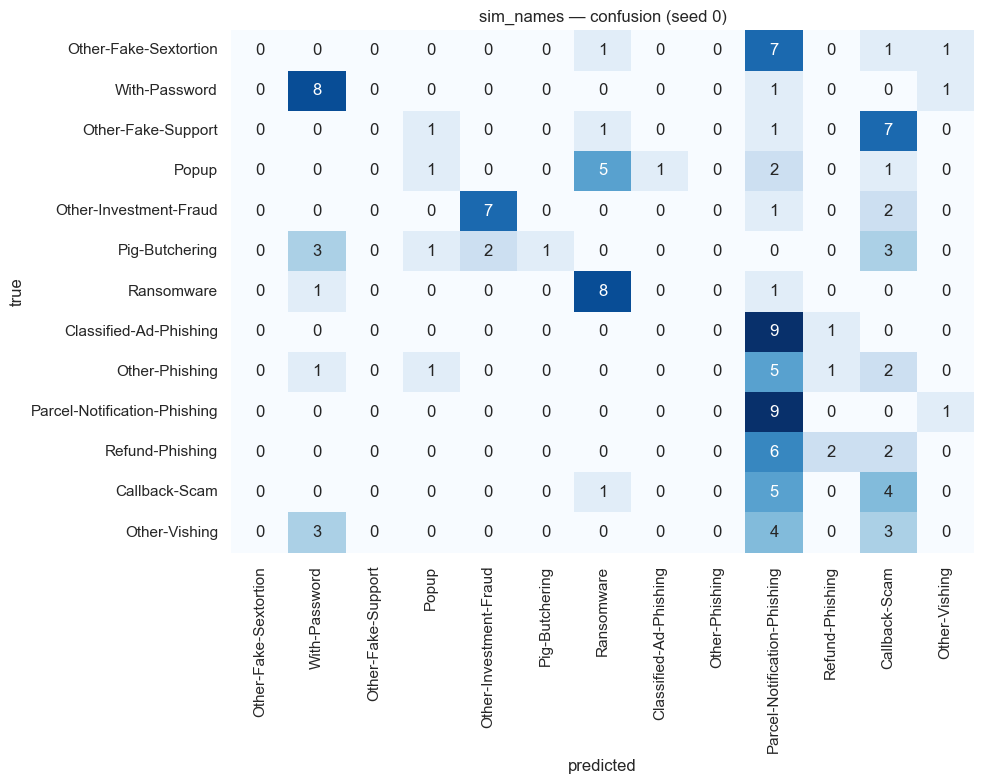

[sim_names] paires les plus confondues (seed 0):


,true,pred,count
0,Phishing/Classified-Ad-Phishing,Phishing/Parcel-Notification-Phishing,9
1,Fraud/Fake-Sextortion/Other-Fake-Sextortion,Phishing/Parcel-Notification-Phishing,7
2,Fraud/Fake-Support/Other-Fake-Support,Phishing/Vishing/Callback-Scam,7
3,Phishing/Refund-Phishing,Phishing/Parcel-Notification-Phishing,6
4,Fraud/Fake-Support/Popup,Malware/Ransomware,5
5,Phishing/Other-Phishing,Phishing/Parcel-Notification-Phishing,5
6,Phishing/Vishing/Callback-Scam,Phishing/Parcel-Notification-Phishing,5
7,Phishing/Vishing/Other-Vishing,Phishing/Parcel-Notification-Phishing,4
8,Fraud/Investment-Fraud/Pig-Butchering,Fraud/Fake-Sextortion/With-Password,3
9,Fraud/Investment-Fraud/Pig-Butchering,Phishing/Vishing/Callback-Scam,3


[sim_names] 90/130 erreurs (seed 0)
-> artifacts/errors_sim_names_seed0.csv


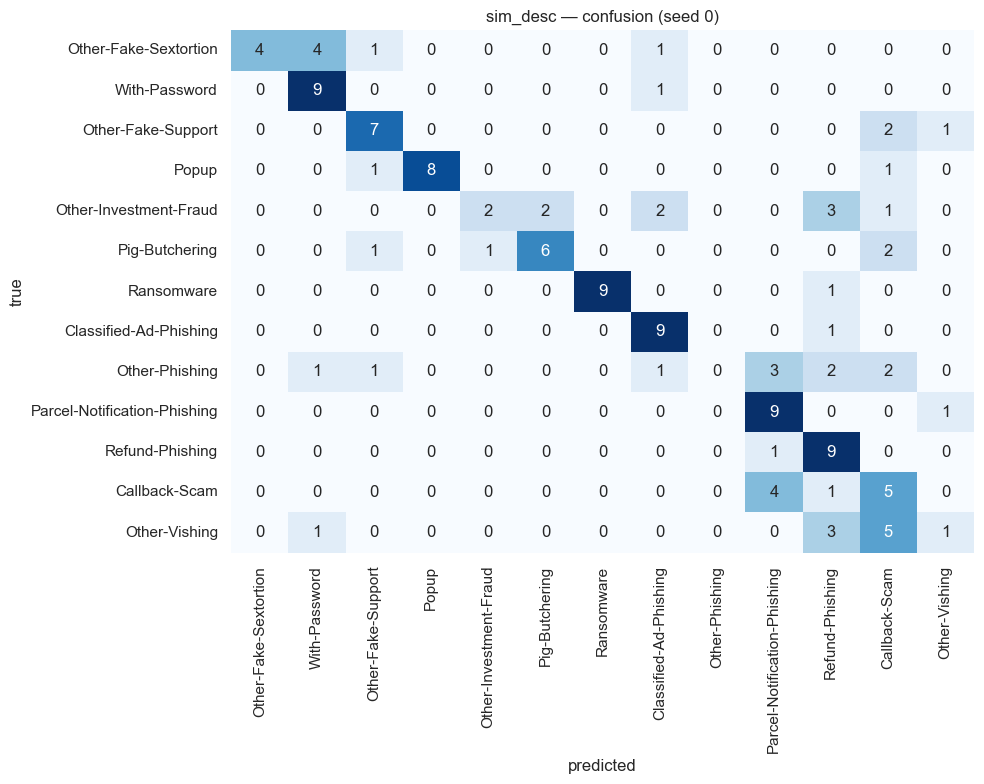

[sim_desc] paires les plus confondues (seed 0):


,true,pred,count
0,Phishing/Vishing/Other-Vishing,Phishing/Vishing/Callback-Scam,5
1,Fraud/Fake-Sextortion/Other-Fake-Sextortion,Fraud/Fake-Sextortion/With-Password,4
2,Phishing/Vishing/Callback-Scam,Phishing/Parcel-Notification-Phishing,4
3,Fraud/Investment-Fraud/Other-Investment-Fraud,Phishing/Refund-Phishing,3
4,Phishing/Other-Phishing,Phishing/Parcel-Notification-Phishing,3
5,Phishing/Vishing/Other-Vishing,Phishing/Refund-Phishing,3
6,Fraud/Fake-Support/Other-Fake-Support,Phishing/Vishing/Callback-Scam,2
7,Fraud/Investment-Fraud/Other-Investment-Fraud,Fraud/Investment-Fraud/Pig-Butchering,2
8,Fraud/Investment-Fraud/Other-Investment-Fraud,Phishing/Classified-Ad-Phishing,2
9,Fraud/Investment-Fraud/Pig-Butchering,Phishing/Vishing/Callback-Scam,2


[sim_desc] 52/130 erreurs (seed 0)
-> artifacts/errors_sim_desc_seed0.csv


In [110]:
_ = diagnostics("sim_names", keep0_names)
_ = diagnostics("sim_desc", keep0_desc)


## Métriques agrégées (mean ± std, 5 seeds)

In [111]:
print("linear_probe_8 (R8):"); display(agg_metrics(res).style.format("{:.3f}"))
print("linear_probe_3 (R3):"); display(agg_metrics(res3).style.format("{:.3f}"))


linear_probe_8 (R8):


,mean,std
metric,,
leaf_accuracy,0.737,0.019
leaf_macro_f1,0.722,0.022
h_micro_f1,0.840,0.020
h_samples_f1,0.838,0.021
h_macro_f1,0.782,0.022
hf1_auc,0.671,0.007


linear_probe_3 (R3):


,mean,std
metric,,
leaf_accuracy,0.648,0.048
leaf_macro_f1,0.633,0.055
h_micro_f1,0.776,0.044
h_samples_f1,0.778,0.043
h_macro_f1,0.703,0.054
hf1_auc,0.565,0.011


## Analyse des erreurs (seed 0) — diagnostics par système (D-08)

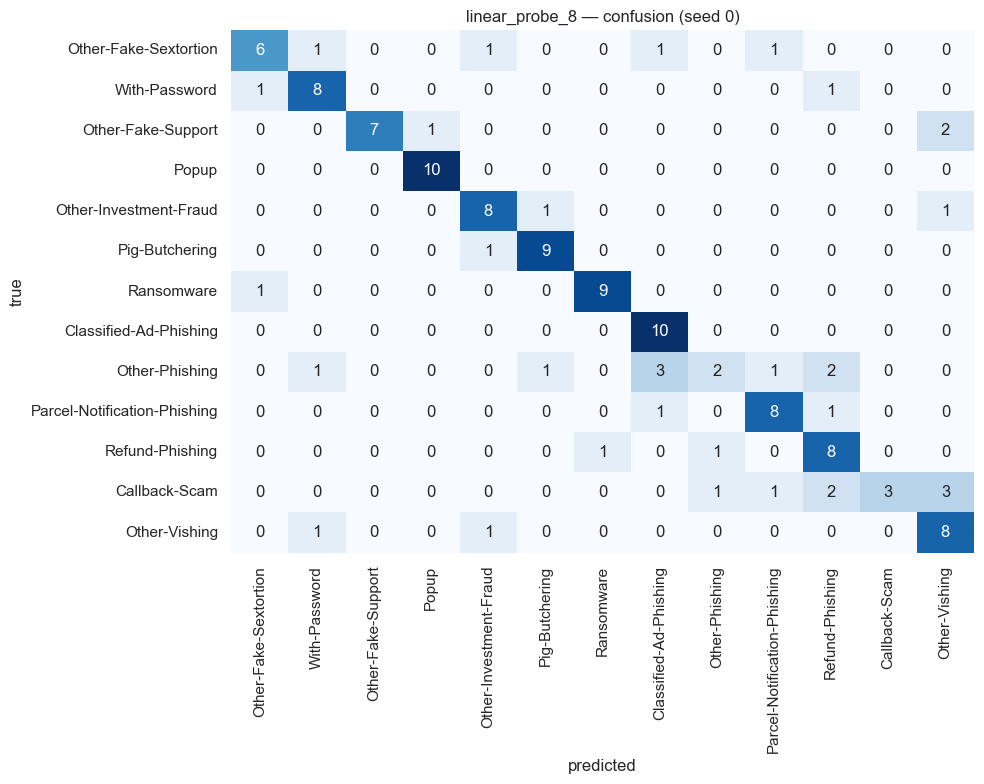

[linear_probe_8] paires les plus confondues (seed 0):


,true,pred,count
0,Phishing/Other-Phishing,Phishing/Classified-Ad-Phishing,3
1,Phishing/Vishing/Callback-Scam,Phishing/Vishing/Other-Vishing,3
2,Fraud/Fake-Support/Other-Fake-Support,Phishing/Vishing/Other-Vishing,2
3,Phishing/Other-Phishing,Phishing/Refund-Phishing,2
4,Phishing/Vishing/Callback-Scam,Phishing/Refund-Phishing,2
5,Fraud/Fake-Sextortion/Other-Fake-Sextortion,Fraud/Investment-Fraud/Other-Investment-Fraud,1
6,Fraud/Fake-Sextortion/Other-Fake-Sextortion,Phishing/Classified-Ad-Phishing,1
7,Fraud/Fake-Sextortion/Other-Fake-Sextortion,Phishing/Parcel-Notification-Phishing,1
8,Fraud/Fake-Sextortion/Other-Fake-Sextortion,Fraud/Fake-Sextortion/With-Password,1
9,Fraud/Fake-Sextortion/With-Password,Phishing/Refund-Phishing,1


[linear_probe_8] 34/130 erreurs (seed 0)
-> artifacts/errors_linear_probe_8_seed0.csv


In [112]:
err8 = diagnostics("linear_probe_8", keep0)


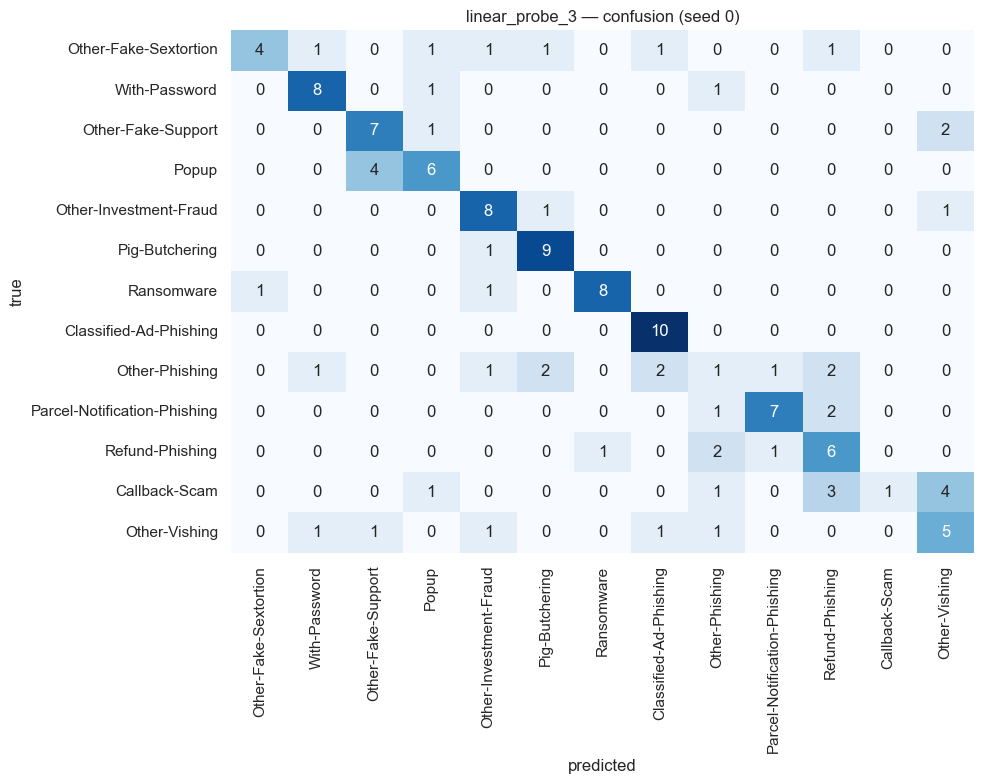

[linear_probe_3] paires les plus confondues (seed 0):


,true,pred,count
0,Fraud/Fake-Support/Popup,Fraud/Fake-Support/Other-Fake-Support,4
1,Phishing/Vishing/Callback-Scam,Phishing/Vishing/Other-Vishing,4
2,Phishing/Vishing/Callback-Scam,Phishing/Refund-Phishing,3
3,Fraud/Fake-Support/Other-Fake-Support,Phishing/Vishing/Other-Vishing,2
4,Phishing/Other-Phishing,Fraud/Investment-Fraud/Pig-Butchering,2
5,Phishing/Other-Phishing,Phishing/Refund-Phishing,2
6,Phishing/Other-Phishing,Phishing/Classified-Ad-Phishing,2
7,Phishing/Parcel-Notification-Phishing,Phishing/Refund-Phishing,2
8,Phishing/Refund-Phishing,Phishing/Other-Phishing,2
9,Fraud/Fake-Sextortion/Other-Fake-Sextortion,Fraud/Investment-Fraud/Other-Investment-Fraud,1


[linear_probe_3] 50/130 erreurs (seed 0)
-> artifacts/errors_linear_probe_3_seed0.csv


In [113]:
err3 = diagnostics("linear_probe_3", keep03)


In [117]:
# Aperçu des erreurs linear_probe_8 (seed 0) — l'export CSV est fait par diagnostics().
display(err8[["leaf_label", "pred", "text"]]
        .assign(text=lambda d: d.text.str.slice(0, 300)).head(15))


,leaf_label,pred,text
0,Fraud/Fake-Sextortion/Other-Fake-Sextortion,Fraud/Investment-Fraud/Other-Investment-Fraud,"The only ""ID"" of the scammer I have is their B..."
2,Fraud/Fake-Sextortion/Other-Fake-Sextortion,Phishing/Classified-Ad-Phishing,Thank you for looking into this. The problem I...
3,Fraud/Fake-Sextortion/Other-Fake-Sextortion,Phishing/Parcel-Notification-Phishing,"Hello, \n\nI've received again an email with t..."
5,Fraud/Fake-Sextortion/Other-Fake-Sextortion,Fraud/Fake-Sextortion/With-Password,"Hello, \nMy mother’s email is hacked and they ..."
16,Fraud/Fake-Sextortion/With-Password,Phishing/Refund-Phishing,Subject: A b 0ut your p@ ssw0rd\n\nH ell o.\n\...
19,Fraud/Fake-Sextortion/With-Password,Fraud/Fake-Sextortion/Other-Fake-Sextortion,"Dear julesou@bluemail.ch,\n\n\n\nI regret to i..."
22,Fraud/Fake-Support/Other-Fake-Support,Phishing/Vishing/Other-Vishing,My elderly mother received a phone call from s...
24,Fraud/Fake-Support/Other-Fake-Support,Phishing/Vishing/Other-Vishing,I received a phone call at 19.31 on Thursday 1...
25,Fraud/Fake-Support/Other-Fake-Support,Fraud/Fake-Support/Popup,"A security check from ""Microsoft"" wanted me to..."
45,Fraud/Investment-Fraud/Other-Investment-Fraud,Phishing/Vishing/Other-Vishing,This number is calling me everyday and is bein...


## Espace latent (test, seed 0)

_Score de silhouette cosinus — plus élevé = clusters par étiquette plus nets (avant/après SetFit)._

In [115]:
def silhouette(emb, labels) -> float:
    """Cosine silhouette score — higher = tighter/cleaner per-label clusters.

    A single number to back the before/after-SetFit latent-space plots: does the
    contrastive step actually separate the classes better, or degrade the geometry?
    """
    from sklearn.metrics import silhouette_score

    return float(silhouette_score(np.asarray(emb), list(labels), metric="cosine"))


silhouette (cosinus) des embeddings gelés par feuille: 0.070


/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


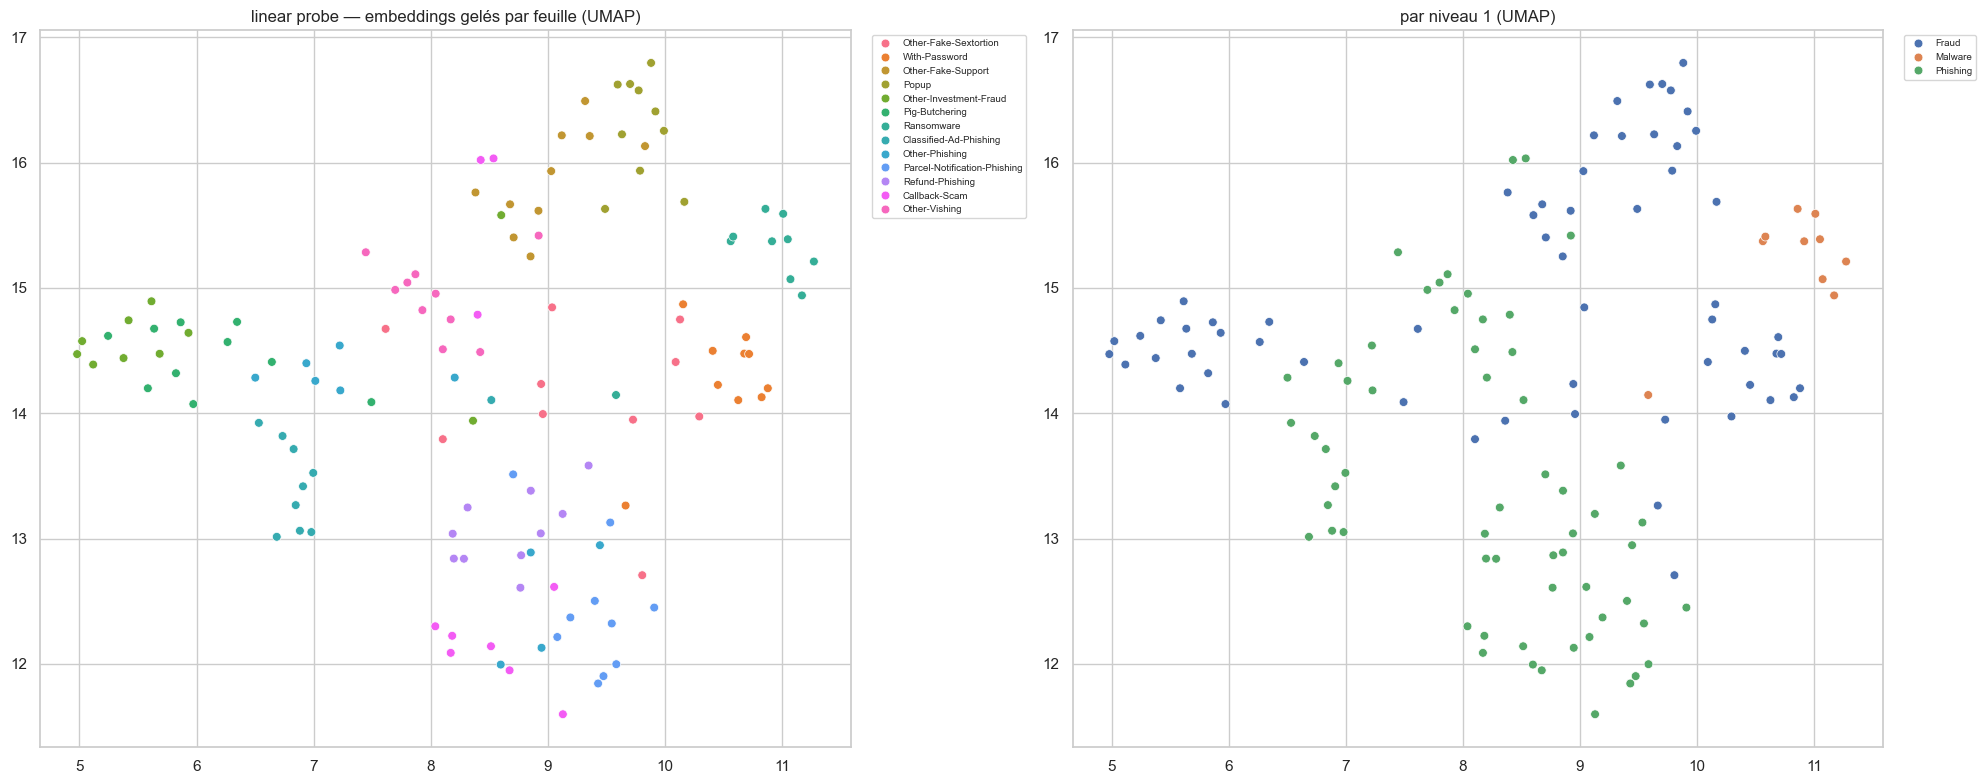

In [116]:
te0 = keep0["te"]
Xte0 = emb_all[te0._id.values]
sil = silhouette(Xte0, te0.leaf_label.tolist())
print(f"silhouette (cosinus) des embeddings gelés par feuille: {sil:.3f}")
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
h.plot_latent(Xte0, te0.leaf_label.tolist(), method="umap", ax=ax[0],
              title="linear probe — embeddings gelés par feuille (UMAP)")
h.plot_latent(Xte0, te0.lvl1.tolist(), method="umap", ax=ax[1],
              title="par niveau 1 (UMAP)")
plt.tight_layout(); plt.show()